## CS336 playground

In [1]:
import time
import torch
import os
import cs336_basics.ron_adamw_optimizer as ron_adamw_optimizer
import cs336_basics.ron_bpe_tokenizer as ron_bpe_tokenizer
import cs336_basics.ron_causal_multihead_self_attention_with_rope as ron_causal_multihead_self_attention_with_rope
import cs336_basics.ron_cross_entropy as ron_cross_entropy
import cs336_basics.ron_data_loader as ron_data_loader
import cs336_basics.ron_embedding as ron_embedding
import cs336_basics.ron_linear as ron_linear
import cs336_basics.ron_multihead_self_attention as ron_multihead_self_attention
import cs336_basics.ron_rmsnorm as ron_rmsnorm
import cs336_basics.ron_rope as ron_rope
import cs336_basics.ron_scaled_dot_product_attention as ron_scaled_dot_product_attention
import cs336_basics.ron_softmax as ron_softmax
import cs336_basics.ron_swiglu as ron_swiglu
import cs336_basics.ron_train_bpe as ron_train_bpe
import cs336_basics.ron_transformer_lm as ron_transformer_lm
import cs336_basics.ron_checkpointing as ron_checkpointing

In [2]:
# from the 7.2 secion

vocab_size = 10000
context_length = 256
d_model = 512
d_ff = 1344
rope_theta = 10000
num_layers = 4
num_heads = 16
batch_size = 16 # fits in 6GB Nvidia 2060
batch_size = 32
device = (
    (torch.cuda.is_available() and 'cuda') or
    (torch.backends.mps.is_available() and 'mps') or
    "cpu"
)

!wget -q -nc https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt -O /tmp/tiny_shakespeare.txt
!wget -q -nc https://huggingface.co/datasets/roneneldan/TinyStories/resolve/main/TinyStoriesV2-GPT4-train.txt -O ../data/TinyStoriesV2-GPT4-train.txt
!wget -q -nc https://dgoldberg.sdsu.edu/515/harrypotter.txt -O /tmp/harrypotter.txt

datasets = {
   'tinystories'            : '../data/TinyStoriesV2-GPT4-train.txt',
   'shakespeare'            : '/tmp/tiny_shakespeare.txt',
   'book'                   : '/tmp/harrypotter.txt',
   'tinystories_validation' : '../data/TinyStoriesV2-GPT4-valid.txt',
}
vocab_dataset = 'tinystories_validation'
training_dataset = 'tinystories_validation'


## BPE training

In [3]:
"""
    vocab size of 1000 on TinyStoriesV2-GPT4-valid.txt  
    isn't horrible for CPU-based interactive notebook use.
    It takes 16 seconds to train and makes words like " Sally" and " helped" 
    into single tokens. Maybe roughly the vocab of a preschooler :)

    vocab size of 10000 on TinyStoriesV2-GPT4-valid.txt takes like 
    three minutes. and makes words like " sinking" and " ribbit".

    Shakespeare's about 3 minutes as well. 
"""
def get_vocab_and_merges(dataset='tinystories',vocab_size=vocab_size):
    vocab_cache = f"./tmp/bpe_{dataset}_{vocab_size}.saved"
    if not os.path.exists(vocab_cache):
        vocab_source = datasets[dataset]
        vocab,merges = ron_train_bpe.train_bpe(vocab_source,vocab_size,["<|endoftext|>"])
        obj = {"vocab": vocab,"merges": merges}
        torch.save(obj, vocab_cache)
    else:
        obj = torch.load(vocab_cache)
        vocab,merges = obj['vocab'],obj['merges']
    return vocab,merges
print(vocab_dataset)
vocab,merges = get_vocab_and_merges(vocab_dataset)
print(merges[-10:])

tinystories_validation
[(b' s', b'ly'), (b' s', b'inking'), (b' ro', b'les'), (b' ro', b'amed'), (b' ribb', b'it'), (b' res', b'pecting'), (b' rele', b'asing'), (b' ref', b'using'), (b' rain', b'coat'), (b' rac', b'ers')]


## BPE class

In [4]:
tokenizer = ron_bpe_tokenizer.RonBPETokenizer(vocab,merges)
tokens    = list(tokenizer.encode_iterable(["Hello world"," ","Good bye"]))
print(tokens)
print(tokenizer.decode(tokens))

[1202, 1592, 32, 2093, 5449]
Hello world Good bye


### Make a nice training dataset with that tokenizer

In [5]:
import numpy as np
import tqdm

def get_tokenized_dataset(dataset, vocab_dataset, vocab_size, dtype=np.uint16):
    out_path = f"./tmp/{dataset}_{vocab_dataset}_{vocab_size}.uint16"
    if not os.path.exists(out_path):
        print("creating ", out_path, " please be patient...")
        tokenizer = ron_bpe_tokenizer.RonBPETokenizer(*get_vocab_and_merges(vocab_dataset,vocab_size))
        data_source = datasets[dataset]
        with open(out_path, "ab") as fout:
            with open(data_source, "r", encoding="utf-8",errors="ignore") as fin:
                for line in tqdm.tqdm(fin):
                    toks = tokenizer.encode(line + "\n")
                    toks_np = np.asarray(toks, dtype=dtype)
                    fout.write(toks_np.tobytes())
    print(f"using {out_path}")
    token_ds = np.memmap(out_path, dtype=np.uint16, mode="r")
    return token_ds

token_ds = get_tokenized_dataset(training_dataset, vocab_dataset, vocab_size)
token_ds[0:10]

creating  ./tmp/tinystories_validation_tinystories_validation_10000.uint16  please be patient...


157832it [00:19, 7942.99it/s] 

using ./tmp/tinystories_validation_tinystories_validation_10000.uint16


memmap([117, 860, 491, 502, 266, 326, 605, 371, 262, 908], dtype=uint16)

## My Transformer model


In [6]:
import cs336_basics.ron_transformer_lm as ron_transformer_lm

tlm = ron_transformer_lm.TransformerLM(
    d_model=d_model,
    num_heads=num_heads,
    d_ff = d_ff,
    max_seq_len=context_length,
    theta=rope_theta,
    vocab_size=vocab_size,
    context_length=context_length,
    num_layers=num_layers
    )
tlm.to(device)
inputs = torch.tensor([tokenizer.encode("Hello world")])
tlm.forward(inputs)

tensor([[[-0.1849,  0.0829,  0.1344,  ..., -0.1216,  0.2874,  0.0315],
         [-0.0623,  0.4379, -0.2065,  ...,  0.3820,  0.2008, -0.1359]]],
       device='mps:0', grad_fn=<ViewBackward0>)

### Predict words

* Expected to be quite random here - no training occurred

In [7]:
def predict_words(
        tlm: ron_transformer_lm.TransformerLM,
        tokenizer: ron_bpe_tokenizer.RonBPETokenizer,
        num_tokens_to_generate = 50,
        initial_text: str = "The",
        debug = False
):
    generated_tokens = tokenizer.encode(initial_text)
    for _ in range(num_tokens_to_generate):
        seq_len = len(generated_tokens)
        tokens_tensor = torch.tensor([generated_tokens])
        with torch.no_grad():
            predictions = tlm.forward(tokens_tensor)  # (1, seq_len, vocab_size)
        last_logits = predictions[0, -1]
        #next_token_id = last_logits.argmax().item()
        probs = ron_softmax.softmax(last_logits,-1)
        next_token_id = torch.multinomial(probs, num_samples=1).item()
        if debug and (_ == num_tokens_to_generate-1):
            all_logit_tokens = predictions[0].cpu().numpy()
            for i, logits in enumerate(all_logit_tokens):
                shifted_logits = logits - np.max(logits)
                probs = np.exp(shifted_logits)
                probs = probs / probs.sum()

                top5_ids = np.argsort(probs)[-5:][::-1]
                top5_tokens = [tokenizer.decode([idx]) for idx in top5_ids]
                top5_probs = probs[top5_ids]

                top5_display = [
                    f"{tok!r}: {prob:.1%}"
                    for tok, prob in zip(top5_tokens, top5_probs)
                ]
                print(
                    f"{tokenizer.decode(generated_tokens[:i+1])} | "
                    f"top 5 next tokens: {", ".join(top5_display)}"
                )
        generated_tokens.append(next_token_id)

    return tokenizer.decode(generated_tokens)

predicted_words = predict_words(tlm,tokenizer,15, debug=True)

The | top 5 next tokens: ' song': 0.0%, 'AT': 0.0%, ' sniffing': 0.0%, ' dragged': 0.0%, ' missed': 0.0%
TheWill | top 5 next tokens: ' Someone': 0.0%, ' shout': 0.0%, ' speed': 0.0%, ' winners': 0.0%, ' chicken': 0.0%
TheWillside | top 5 next tokens: 'Two': 0.0%, 'One': 0.0%, ' incredible': 0.0%, ' P': 0.0%, ' clos': 0.0%
TheWillside blouse | top 5 next tokens: ' shaking': 0.0%, ' waved': 0.0%, 'cles': 0.0%, ' stuffed': 0.0%, 'One': 0.0%
TheWillside blouse petals | top 5 next tokens: ' selfish': 0.0%, ' incredible': 0.0%, ' achieved': 0.0%, ' friendly': 0.0%, ' Tuesday': 0.0%
TheWillside blouse petals lady | top 5 next tokens: ' hooks': 0.0%, ' manners': 0.0%, ' bees': 0.0%, 'Bu': 0.0%, ' Brave': 0.0%
TheWillside blouse petals lady bandages | top 5 next tokens: 'rink': 0.0%, ' kite': 0.0%, ' traveled': 0.0%, 'stri': 0.0%, ' Buddy': 0.0%
TheWillside blouse petals lady bandages chamber | top 5 next tokens: ' touched': 0.0%, ' Brave': 0.0%, ' magnif': 0.0%, ' Shiny': 0.0%, ' neare': 0.0%

## My AdamW Optimizer

In [8]:
my_adamw = ron_adamw_optimizer.AdamW(tlm.parameters())

## My Data Loader

In [9]:
def get_training_batch():
    x,y = ron_data_loader.get_batch(token_ds,batch_size,context_length,device)
    if device == 'mps':
        # TypeError: Trying to convert UInt16 to the MPS backend but it does not have support for that dtype.
        x = x.to('cpu').to(dtype=torch.long).to(device)
        y = y.to('cpu').to(dtype=torch.long).to(device)
    else:
        x = x.to(dtype=torch.long)
        y = y.to(dtype=torch.long)
    return x,y

### Compile the model

Can take 14 seconds for the first forward pass...

Quoting a chatbot: 

> PyTorch (via TorchDynamo + TorchInductor) traces your model the first time you call it, captures the computation graph, and then compiles optimized kernels for your GPU.
>
> What happens:
>
> * First call (slow, e.g. 14s)
>   * TorchDynamo intercepts your Python code.
>   * TorchInductor generates optimized code (usually CUDA kernels).
>   * Compilation is JIT (just-in-time), so it can take several seconds.
> * Subsequent calls (fast, e.g. 0.2s)
>   * The compiled kernels are cached.
>   * PyTorch skips Python dispatch and just runs the optimized kernels.
>
> That’s why you see a huge difference between the first iteration and the rest.

This warning is expected on my cheap old GPU

```
W0901 17:10:39.072000 3071772 torch/_inductor/utils.py:1137] [0/0] Not enough SMs to use max_autotune_gemm mode
```




In [10]:
# warmup to not skew training iter time
if device != 'mps': # fails on 'mps'
    tlm.compile()
    tokens = torch.randint(0, vocab_size, (16, 256), device=device)
    tlm(tokens)


## Training Loop

In [11]:
if reastart_with_a_pretty_good_checkpoint := True:
    cp = 'cp_tinystories_validation_loss_2.0782.pt'
    cp = 'cp_tinystories_validation_tinystories_validation_good.pt'
    ron_checkpointing.load_checkpoint(cp,tlm, my_adamw)


In [12]:
predict_words(tlm,tokenizer,20, debug=True)

The | top 5 next tokens: ' song': 0.0%, 'AT': 0.0%, ' sniffing': 0.0%, ' dragged': 0.0%, ' missed': 0.0%
The tigers | top 5 next tokens: ' Mina': 0.0%, 'fore': 0.0%, ' Izzy': 0.0%, 'law': 0.0%, ' knight': 0.0%
The tigers trading | top 5 next tokens: 'law': 0.0%, ' knight': 0.0%, ' disturbing': 0.0%, 'Bessie': 0.0%, ' juice': 0.0%
The tigers trading staying | top 5 next tokens: ' speak': 0.0%, ' sunflower': 0.0%, ' palm': 0.0%, ' Andy': 0.0%, 'Bessie': 0.0%
The tigers trading staying bre | top 5 next tokens: ' fan': 0.0%, ' mailbox': 0.0%, ' disagree': 0.0%, ' cable': 0.0%, 'ped': 0.0%
The tigers trading staying bre toddler | top 5 next tokens: 'onde': 0.0%, 'bum': 0.0%, ' exch': 0.0%, 'llipop': 0.0%, '�': 0.0%
The tigers trading staying bre toddlerWith | top 5 next tokens: 'udd': 0.0%, ' lemons': 0.0%, 'Two': 0.0%, ' speak': 0.0%, ' buckets': 0.0%
The tigers trading staying bre toddlerWith know | top 5 next tokens: ' beads': 0.0%, 'nie': 0.0%, ' umbrellas': 0.0%, ' comforting': 0.0%, '

'The tigers trading staying bre toddlerWith knowcery DizzyBillyving stomluWow pap splJacky Boo.”hter'

In [13]:
import mlflow
import IPython.display as ipd
import html
import regex as re
def train(model, optimizer, get_batch, device=device, max_training_time = 60 * 60 * 5, num_iters=1000*1000):
    model.to(device)
    model.train()
    best_loss = float('inf')
    with mlflow.start_run():
        mlflow.log_params({
            "device": device,
            "num_iters": num_iters,
            "optimizer": type(optimizer).__name__,
            "model": type(model).__name__
        })
        t0 = time.time()
        next_log_interval = 1
        for it in range(num_iters):
            x, y = get_batch()
            logits = model(x)            # shape: (batch, seq, vocab)
            loss = ron_cross_entropy.cross_entropy(
                logits.view(-1, logits.size(-1)),
                y.view(-1)
            )
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if loss.item() < best_loss:
                best_loss = loss.item()
                cp_name = f"cp_{training_dataset}_{vocab_dataset}.pt"
                ron_checkpointing.save_checkpoint(model, optimizer, it, cp_name)
                print("saved checkpoint ", cp_name, best_loss)

            if it >= next_log_interval or time.time() > max_training_time + t0:
                next_log_interval *= 2
                mlflow.log_metric("loss", loss.item(), step=it)
                mlflow.log_metric("elapsed_time", time.time() - t0, step=it)
                output = predict_words(tlm,tokenizer,100)
                ipd.display(ipd.HTML(f'''
                    <div style="display: grid; grid-template-columns: 1fr 3fr; gap: 1px; border: 1px solid black; padding: 1px;">
                        <div style="border-right: 1px solid black; padding: 5px;">
                            <strong>iter {it}</strong><br>
                            loss: {loss.item():.4f}<br>
                            elapsed: {time.time() - t0:.3f} secs
                        </div>
                        <div style="padding: 1px;">
                            {re.sub("\n+", "<br>", html.escape(output))}
                        </div>
                    </div>
                '''), metadata=dict(isolated=True))
                if time.time() - t0 > max_training_time:
                    break

/Users/rmayer@shotspotter.com/work/cs336/assignment1-basics/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
if retrain:=True:
    train(tlm,my_adamw,get_training_batch,max_training_time=60*60)

/Users/rmayer@shotspotter.com/work/cs336/assignment1-basics/.venv/lib/python3.14/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt


saved checkpoint  cp_tinystories_validation_tinystories_validation.pt


saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt


saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt


...

saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt


saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt


saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt


saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt


saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt
saved checkpoint  cp_tinystories_validation_tinystories_validation.pt


In [24]:
if retrain_more:=False:
    train(tlm,my_adamw,get_training_batch,max_training_time=60*60)

In [16]:
#!cp cp_tinystories_validation_tinystories_validation.pt cp_tinystories_validation_loss_2.0782.pt

In [25]:
# def load_checkpoint(
#     src: str | os.PathLike | typing.BinaryIO | typing.IO[bytes],
#     model: torch.nn.Module,
#     optimizer: torch.optim.Optimizer,
#     ):

ron_checkpointing.load_checkpoint("cp_tinystories_validation_tinystories_validation_good.pt",tlm, my_adamw)

output = predict_words(tlm,tokenizer,100)

output

'The kids bear gave him a present from his head. He was very happy. The bear gave Bob a big kiss and made him smile on his face. They all said thank you to Bob. From that day on, they helped Bob think he could find a nice place to rest when he was tired.\n\n<|endoftext|>\n\nOnce upon a time, in a small town, there was a pale cat named Tom. Tom loved to play with his ball on the floor. One'

In [79]:
s = predict_words(tlm,tokenizer,100, initial_text="Once")
print(s)

Once upon a time, in a small town, there was a silly monkey named Momo. Momo loved to eat bananas. One day, Momo's mom told him to prepare a bananas for the monkey, and Momo would go to the jungle.

Momo's mom said, "Timmy, refused to get ordered bananas." Momo was sad, but he knew Momo was right. He went to the store to get a drink. Momo sat in the corner, feeling the soft mud around him. He started to drink


In [92]:
s = predict_words(tlm,tokenizer,100, initial_text="Lily")
print(s)

Lily ran away from the dog. The dog was all alone and hungry.

Lily went near the tree and shook her ice cream. Her stomach hurt her neck and her broken eyes. It was ruined. She went to her mom, her room, but her ice cream was gone. She could not read it to her mom or tell her what happened.

<|endoftext|>





Tom and Mia are twins. They like to play with their toys. Today, they are


## Attention Pattern Visualization

Visualize attention weights across all layers and heads, matching the approach from
[HelloWorld_Transformer_with_RoPE.ipynb](https://github.com/ramayer/google-colab-examples/blob/main/HelloWorld_Transformer_with_RoPE.ipynb).

The model's `forward()` now accepts `return_attention=True`, returning `(logits, all_attn_weights)`
where `all_attn_weights` is a list of per-layer tensors shaped `(batch, heads, seq, seq)`.

In [33]:
import matplotlib.pyplot as plt


def get_attention_weights(model, tokenizer, text: str = "Once upon a time"):
    """Run the model once and return tokens + per-layer attention weights."""
    tokens = tokenizer.encode(text)
    token_strs = [tokenizer.decode([t]) for t in tokens]
    inputs = torch.tensor([tokens], device=next(model.parameters()).device)

    model.eval()
    with torch.no_grad():
        _, all_attn_weights = model.forward(inputs, return_attention=True)

    return token_strs, all_attn_weights


def plot_attention_weights(
    token_strs,
    all_attn_weights,
    text: str,
    layers=None,   # None = all layers
    heads=None,    # None = average across heads
):
    """Visualize attention patterns from already-computed attention weights."""
    num_layers = len(all_attn_weights)
    layer_indices = layers if layers is not None else list(range(num_layers))

    fig, axes = plt.subplots(
        1,
        len(layer_indices),
        figsize=(5 * len(layer_indices), 5),
        squeeze=False,
    )

    for col, layer_idx in enumerate(layer_indices):
        attn = all_attn_weights[layer_idx][0].cpu().float()  # (heads, seq, seq)
        if heads is not None:
            attn_to_plot = attn[heads]
            title = f"Layer {layer_idx}, Head {heads}"
        else:
            attn_to_plot = attn.mean(dim=0)
            title = f"Layer {layer_idx} (avg heads)"

        ax = axes[0][col]
        im = ax.imshow(attn_to_plot.numpy(), cmap="viridis", aspect="auto", vmin=0)
        ax.set_title(title, fontsize=10)
        ax.set_xticks(range(len(token_strs)))
        ax.set_xticklabels(token_strs, rotation=45, ha="right", fontsize=8)
        ax.set_yticks(range(len(token_strs)))
        ax.set_yticklabels(token_strs, fontsize=8)
        ax.set_xlabel("Key (attended to)")
        ax.set_ylabel("Query (attends from)")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle(f'Attention patterns for: "{text}"', fontsize=12)
    plt.tight_layout()
    plt.show()


def visualize_attention(model, tokenizer, text: str = "Once upon a time", layers=None, heads=None):
    """Convenience wrapper to preserve existing notebook calls."""
    token_strs, all_attn_weights = get_attention_weights(model, tokenizer, text=text)
    plot_attention_weights(
        token_strs=token_strs,
        all_attn_weights=all_attn_weights,
        text=text,
        layers=layers,
        heads=heads,
    )
    return all_attn_weights


In [21]:
# Useful addition: show "current token -> most likely next token" on the y-axis.
# (Can get visually busy for long prompts, so keep prompts short.)

def visualize_attention_with_top_next(
    model,
    tokenizer,
    text: str = "Once upon a time",
    layers=None,          # None = all layers
    heads=None,           # None = average across heads
    show_top_next_on_y=True,
):
    tokens = tokenizer.encode(text)
    token_strs = [tokenizer.decode([t]) for t in tokens]
    inputs = torch.tensor([tokens], device=next(model.parameters()).device)

    model.eval()
    with torch.no_grad():
        logits, all_attn_weights = model.forward(inputs, return_attention=True)

    if show_top_next_on_y:
        top_next_ids = logits[0].argmax(dim=-1).tolist()
        top_next_strs = [tokenizer.decode([idx]) for idx in top_next_ids]
        y_labels = [f"{tok} → {nxt}" for tok, nxt in zip(token_strs, top_next_strs)]
    else:
        y_labels = token_strs

    num_layers = len(all_attn_weights)
    layer_indices = layers if layers is not None else list(range(num_layers))

    fig, axes = plt.subplots(
        1,
        len(layer_indices),
        figsize=(6 * len(layer_indices), 5),
        squeeze=False,
    )

    for col, layer_idx in enumerate(layer_indices):
        attn = all_attn_weights[layer_idx][0].cpu().float()  # (heads, seq, seq)
        if heads is not None:
            attn_to_plot = attn[heads]
            title = f"Layer {layer_idx}, Head {heads}"
        else:
            attn_to_plot = attn.mean(dim=0)
            title = f"Layer {layer_idx} (avg heads)"

        ax = axes[0][col]
        im = ax.imshow(attn_to_plot.numpy(), cmap="viridis", aspect="auto", vmin=0)
        ax.set_title(title, fontsize=10)
        ax.set_xticks(range(len(token_strs)))
        ax.set_xticklabels(token_strs, rotation=45, ha="right", fontsize=8)
        ax.set_yticks(range(len(y_labels)))
        ax.set_yticklabels(y_labels, fontsize=8)
        ax.set_xlabel("Key (attended to)")
        ax.set_ylabel("Query (attends from → top next)")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle(f'Attention patterns for: "{text}"', fontsize=12)
    plt.tight_layout()
    plt.show()

    return all_attn_weights


## Visualize attention weights

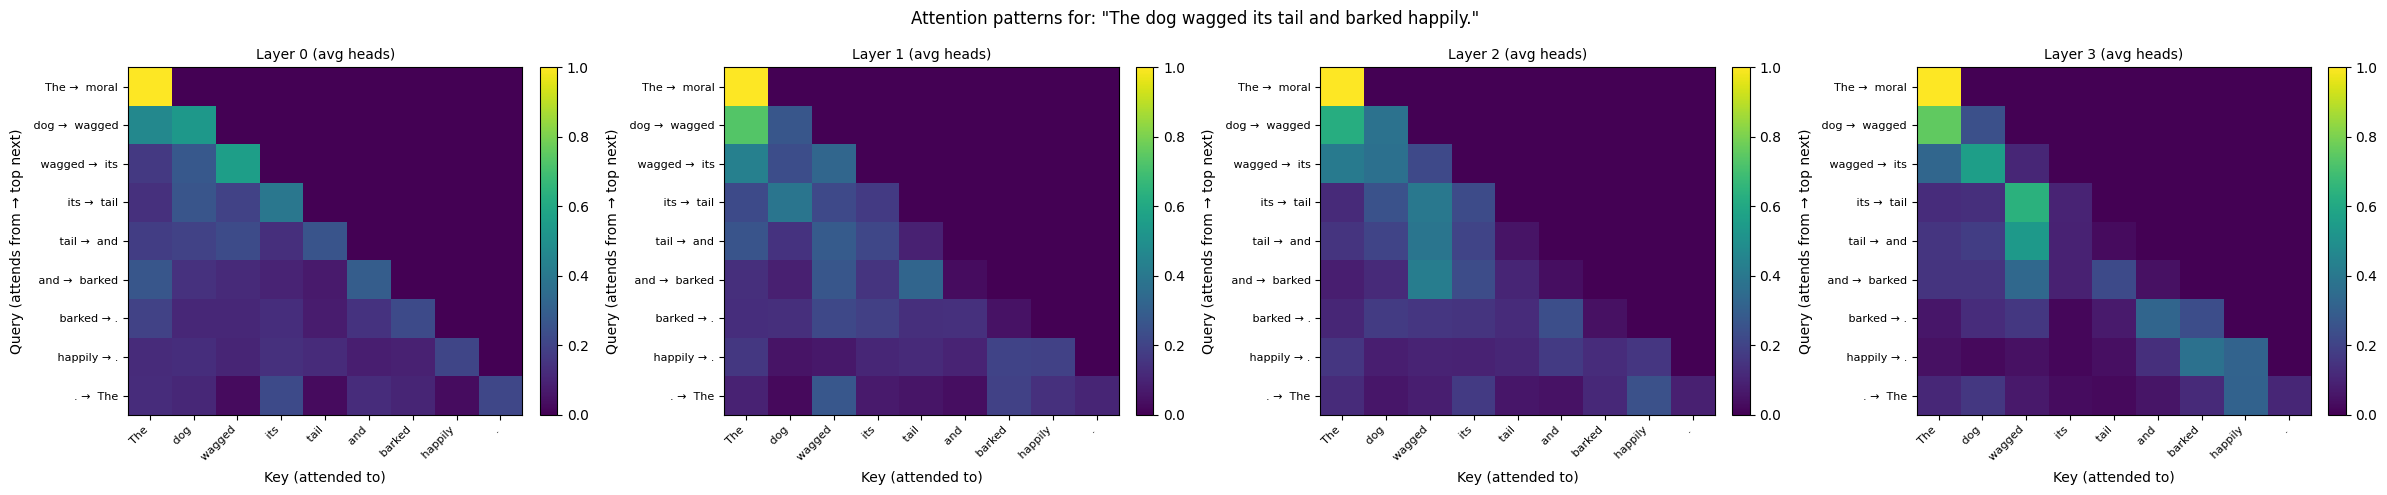

In [54]:
# Visualize all layers (averaged over heads) for a short prompt

prompt = "The dog wagged its tail and barked happily."
attn_weights = visualize_attention_with_top_next(tlm, tokenizer, text=prompt, layers=None, heads=None)


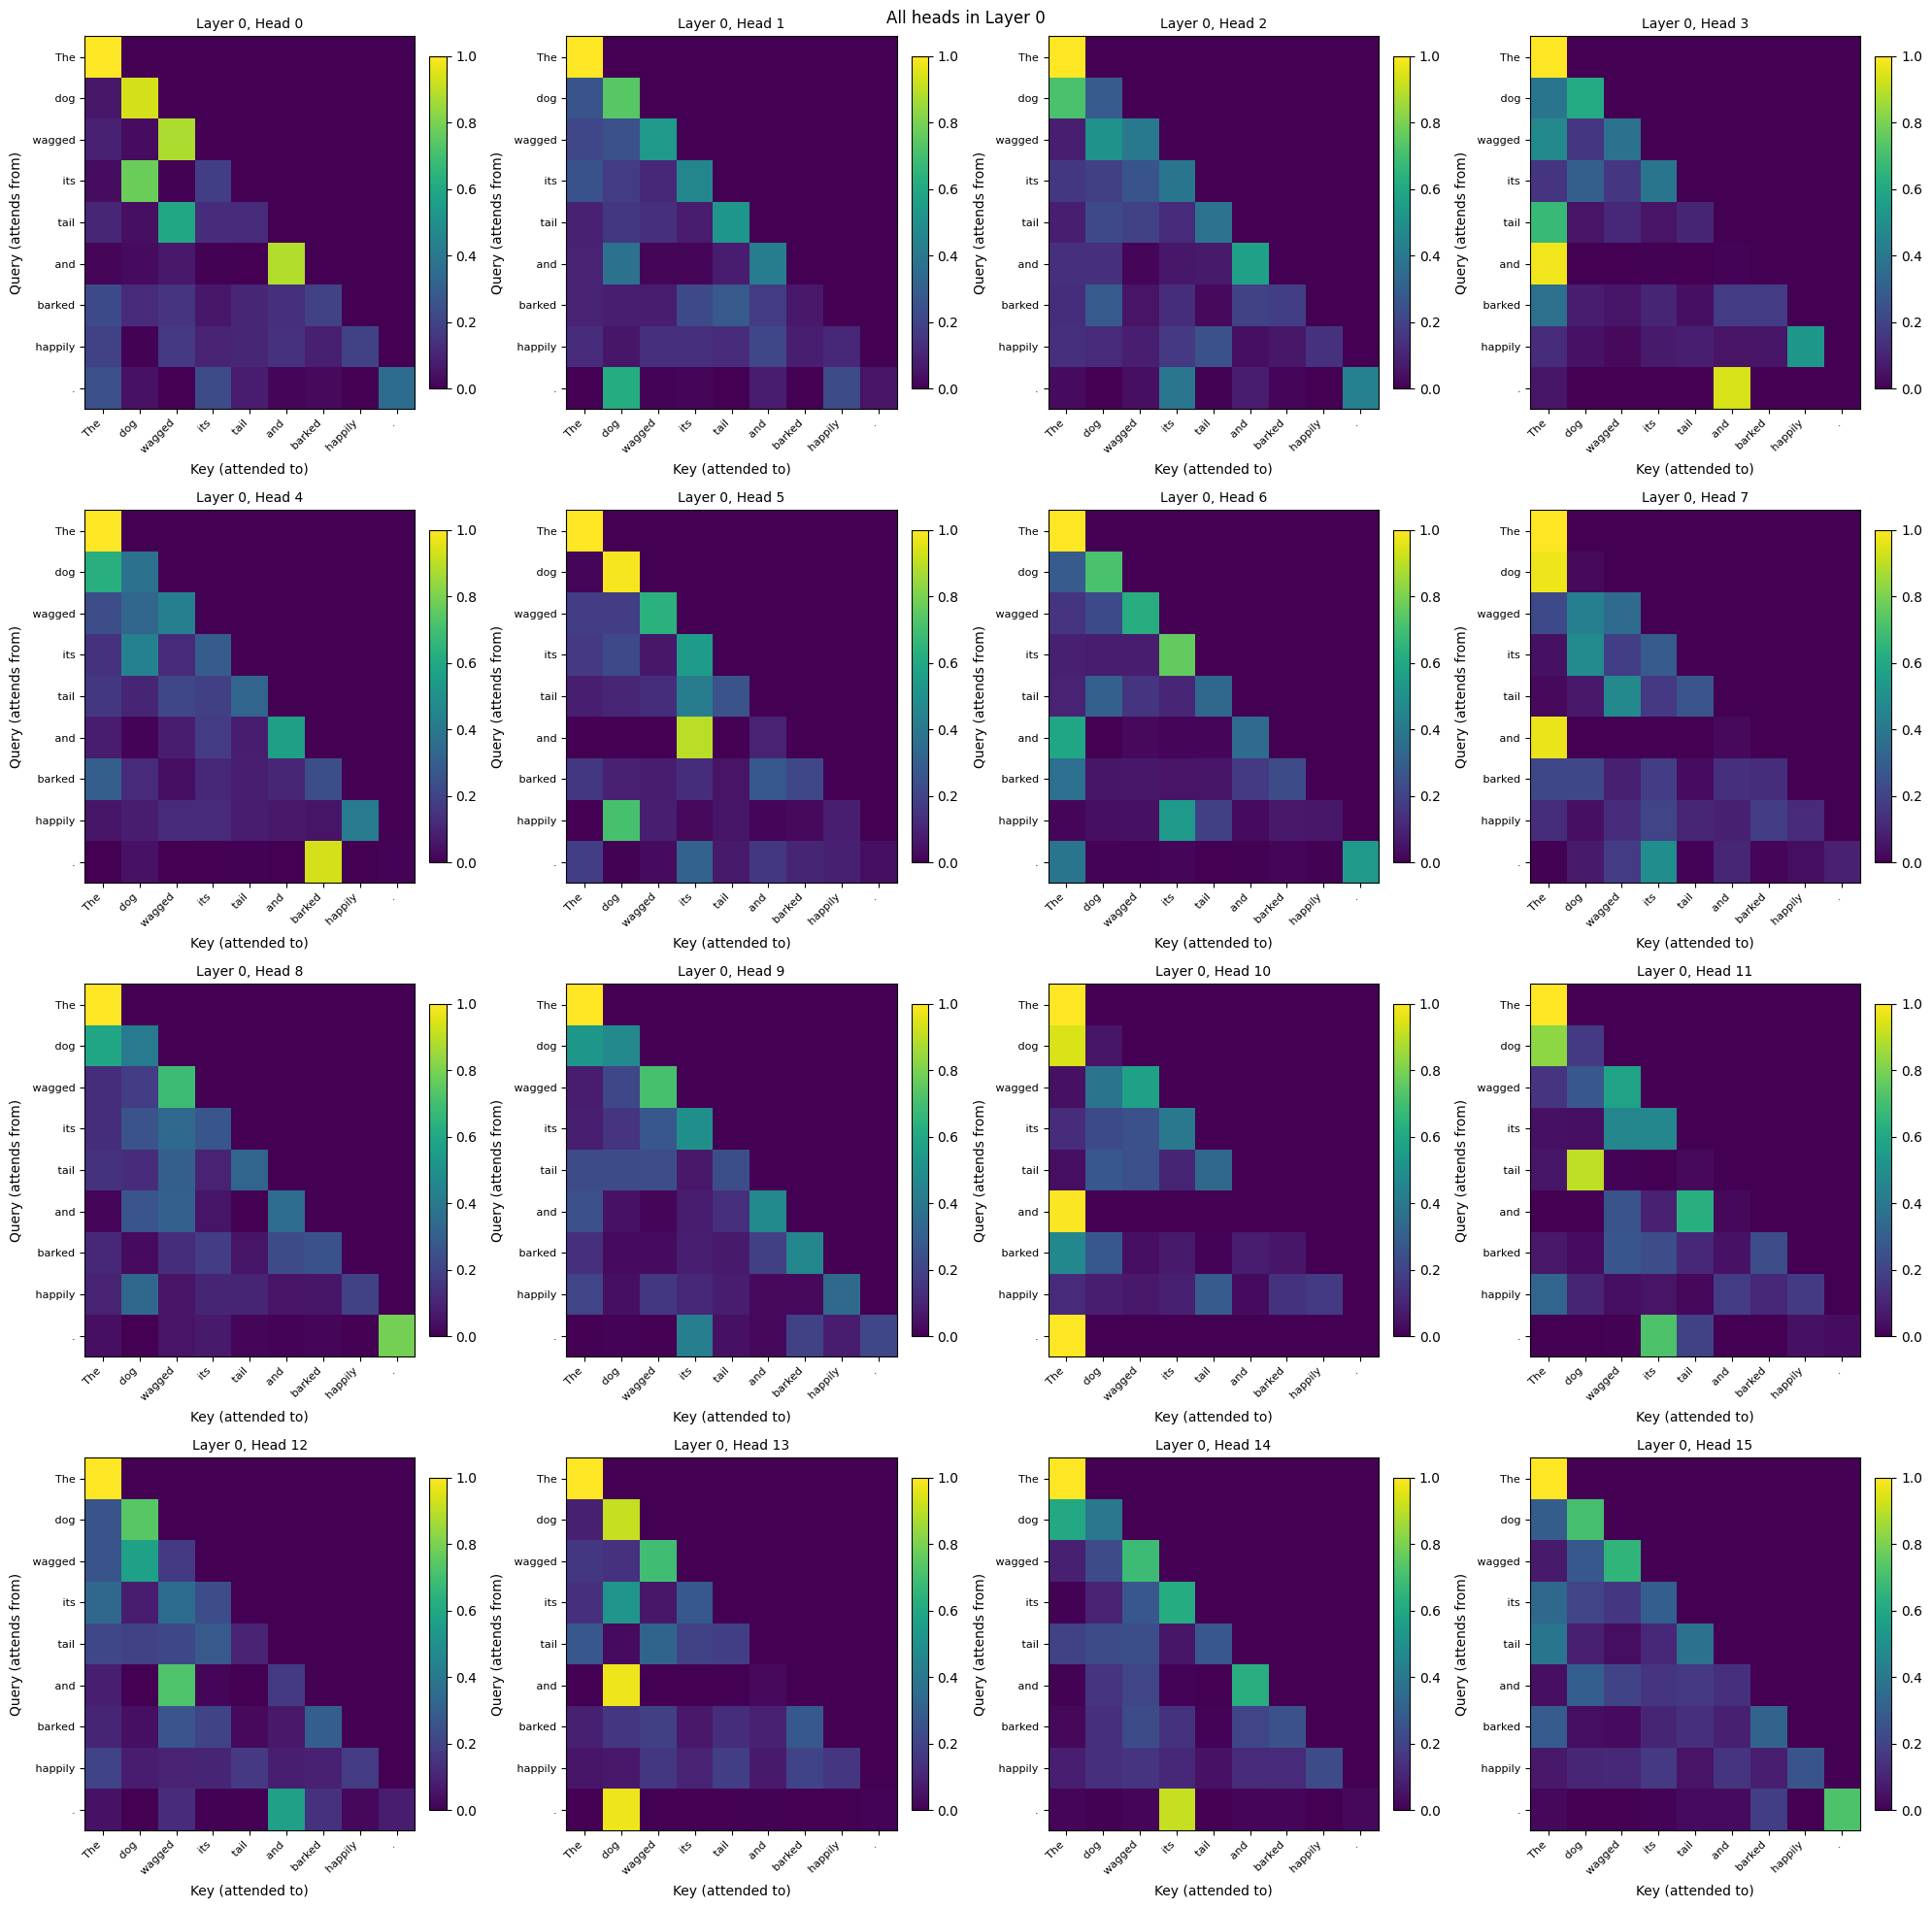

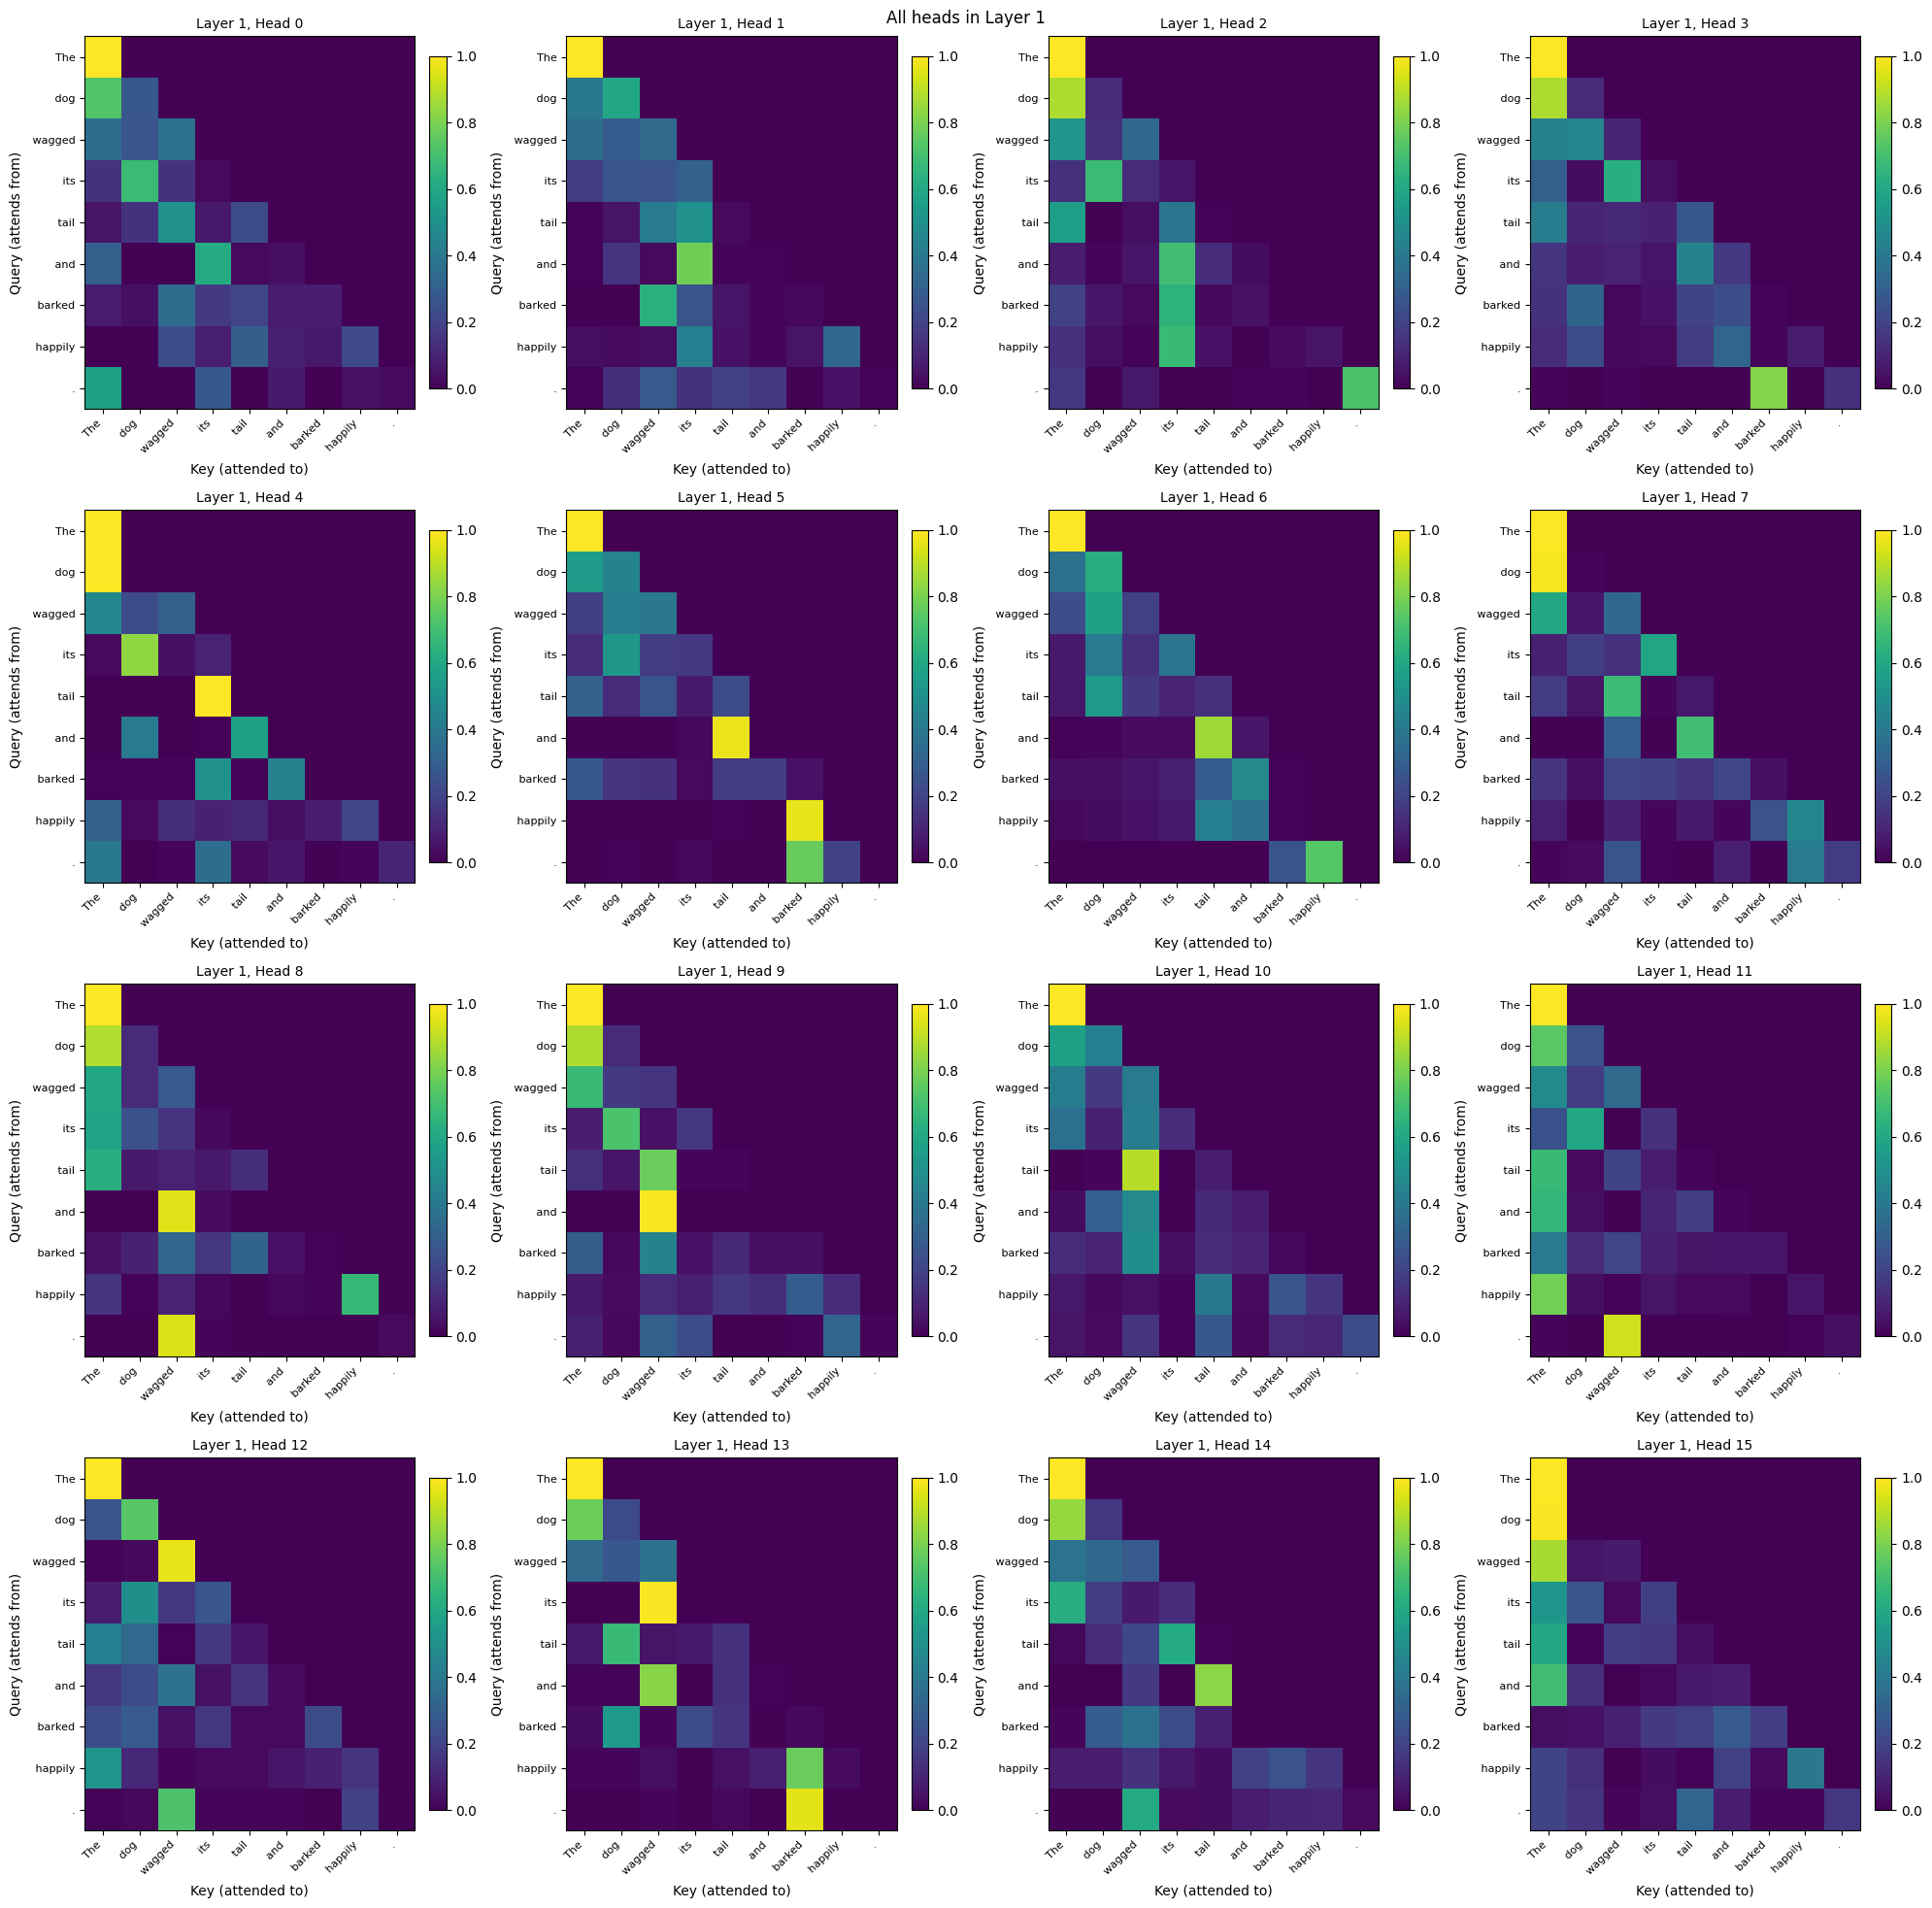

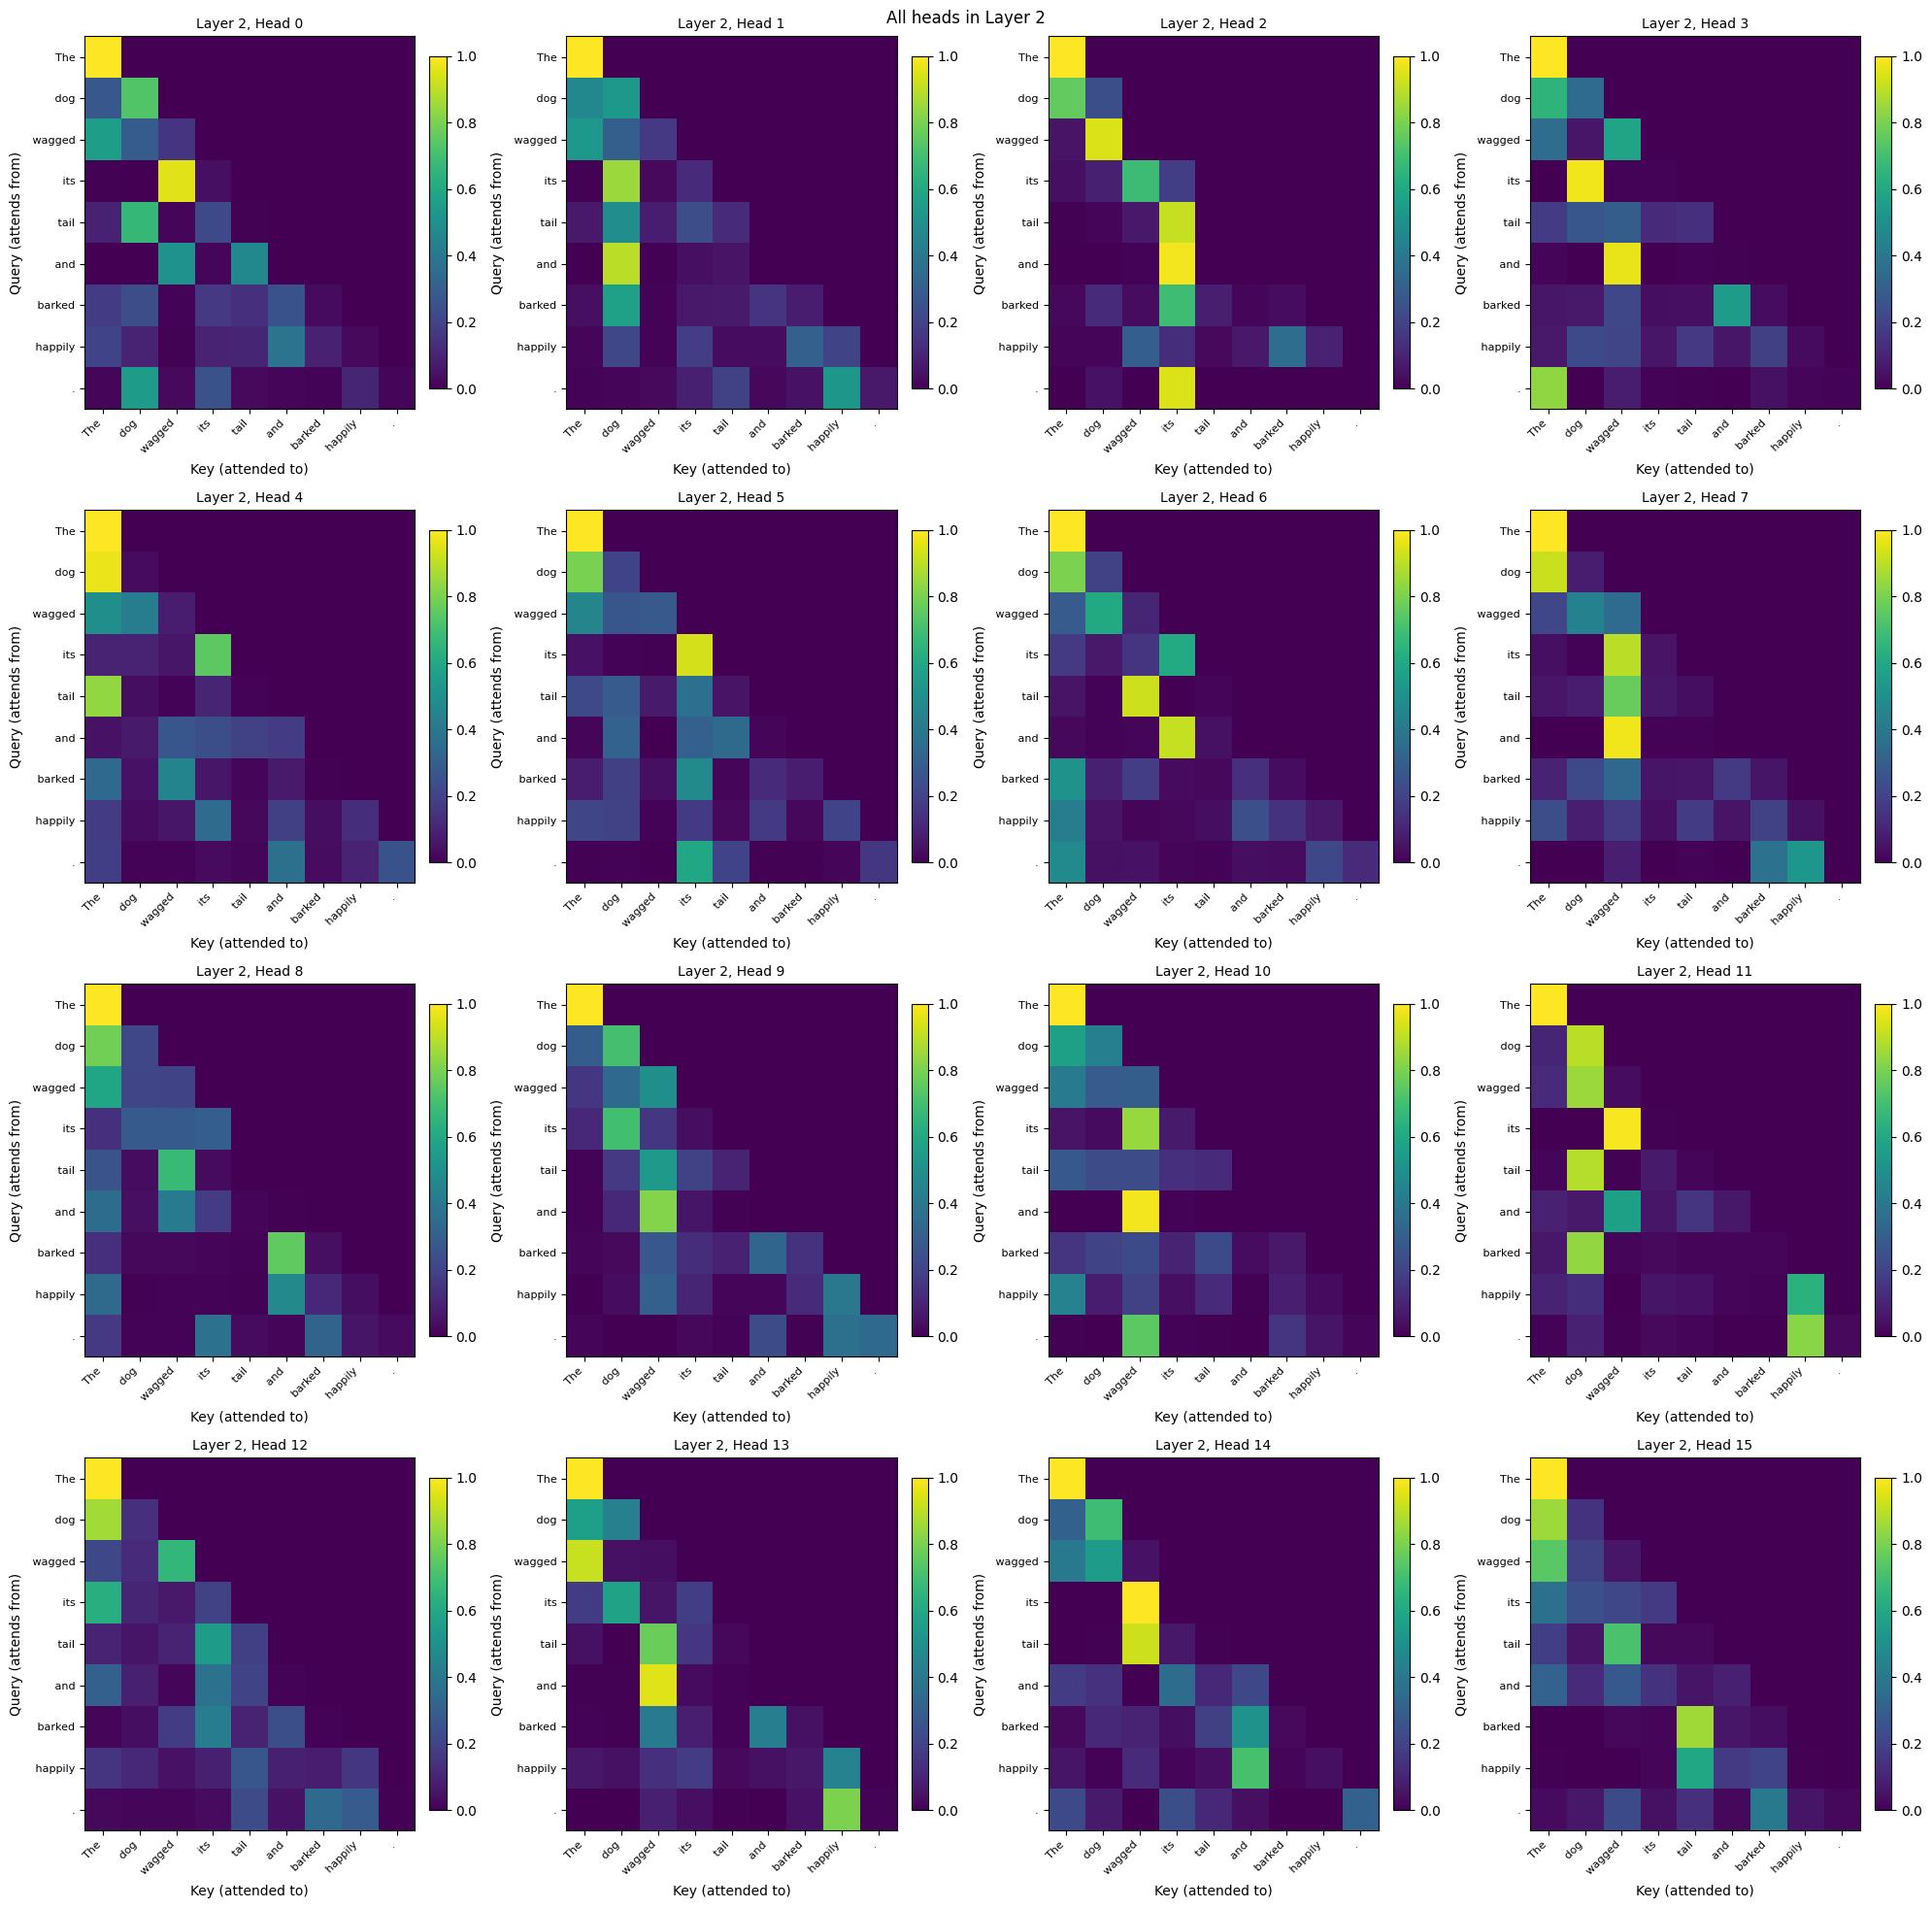

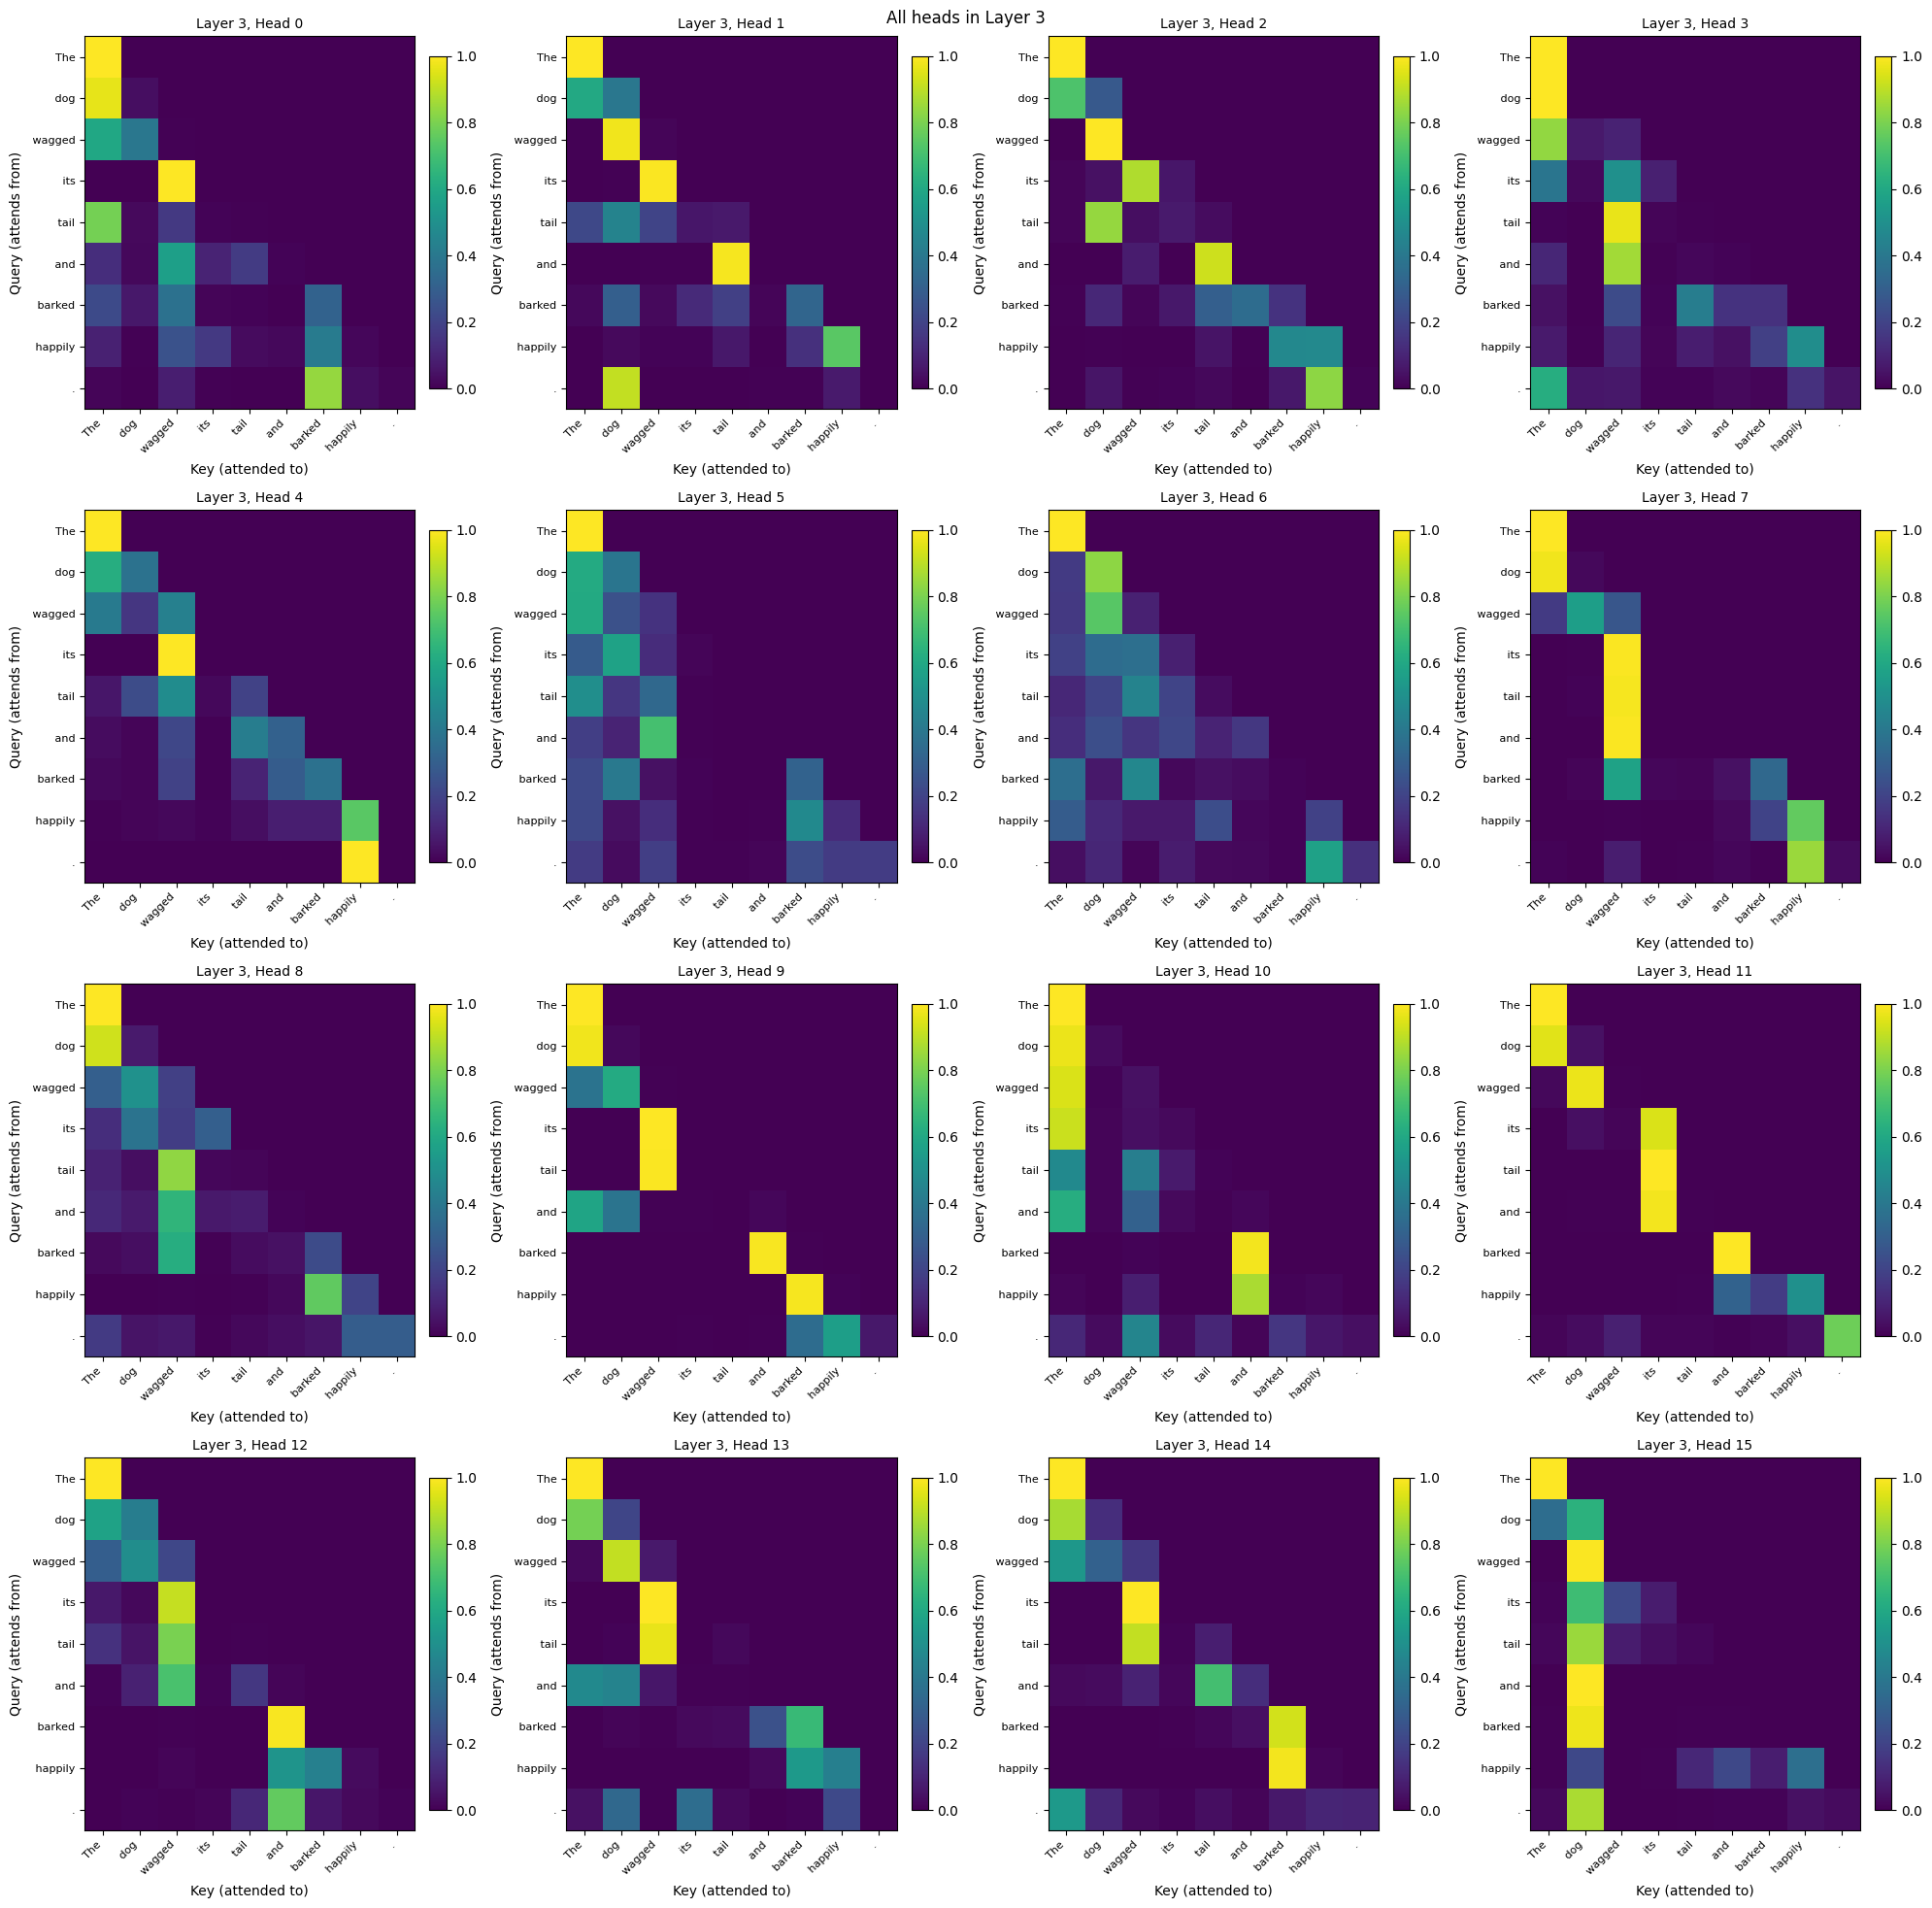

Saved plots and HTML page to: ./tmp/attention_plots/the_dog_wagged_its_tail_and_barked_happily/index.html


In [55]:
def visualize_all_heads_all_layers(attn_weights, tokenizer, prompt, max_heads=None, layers = None):
    """
    Plot every head for every layer.
    attn_weights[layer] is expected to have shape (batch, num_heads, seq, seq).
    """
    tokens = tokenizer.encode(prompt)
    token_strs = [tokenizer.decode([t]) for t in tokens]

    num_layers = len(attn_weights)

    safe_prompt = "".join(c.lower() if c.isalnum() else "_" for c in prompt).strip("_")[:60] or "prompt"
    out_dir = os.path.join("./tmp/attention_plots", safe_prompt)
    os.makedirs(out_dir, exist_ok=True)
    image_paths = []

    if layers is not None:
        layer_indices = layers
    else:
        layer_indices = range(num_layers)

    for layer_idx in layer_indices:
        layer_tensor = attn_weights[layer_idx]  # (batch, heads, seq, seq)
        num_heads = layer_tensor.shape[1]
        heads_to_show = num_heads if max_heads is None else min(max_heads, num_heads)
        ncols = min(4, heads_to_show)
        nrows = (heads_to_show + ncols - 1) // ncols

        fig, axes = plt.subplots(
            nrows,
            ncols,
            figsize=(5 * ncols, 5 * nrows),
            squeeze=False,
        )

        for h in range(heads_to_show):
            r, c = divmod(h, ncols)
            attn = layer_tensor[0, h].detach().cpu().float().numpy()
            ax = axes[r][c]
            im = ax.imshow(attn, cmap="viridis", aspect="auto", vmin=0)
            ax.set_title(f"Layer {layer_idx}, Head {h}", fontsize=10)
            ax.set_xticks(range(len(token_strs)))
            ax.set_xticklabels(token_strs, rotation=45, ha="right", fontsize=8)
            ax.set_yticks(range(len(token_strs)))
            ax.set_yticklabels(token_strs, fontsize=8)
            ax.set_xlabel("Key (attended to)")
            ax.set_ylabel("Query (attends from)")
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        # Hide any unused subplot slots in the last row
        for h in range(heads_to_show, nrows * ncols):
            r, c = divmod(h, ncols)
            axes[r][c].axis("off")

        fig.suptitle(f"All heads in Layer {layer_idx}", fontsize=12)
        plt.tight_layout()

        image_name = f"layer_{layer_idx:02d}_heads_{heads_to_show:02d}.png"
        image_path = os.path.join(out_dir, image_name)
        fig.savefig(image_path, dpi=160, bbox_inches="tight")
        image_paths.append(image_name)

        plt.show()
        plt.close(fig)

    html_path = os.path.join(out_dir, "index.html")
    with open(html_path, "w", encoding="utf-8") as f:
        f.write("<html><head><meta charset='utf-8'><title>Attention Plots</title></head><body>")
        f.write(f"<h1>Attention plots for prompt: {prompt}</h1>")
        for image_name in image_paths:
            f.write(f"<h2>{image_name}</h2><img src='{image_name}' style='max-width:100%;'><hr>")
        f.write("</body></html>")

    print(f"Saved plots and HTML page to: {html_path}")
    return html_path
  
html_overview = visualize_all_heads_all_layers(attn_weights, tokenizer, prompt, max_heads=16)


In [48]:
from pathlib import Path
import subprocess

html_path = Path(html_overview).resolve()

# macOS: open in Chrome
subprocess.run(["open", "-a", "Google Chrome", str(html_path)])

# macOS: open in Firefox (use this instead if preferred)
# subprocess.run(["open", "-a", "Firefox", str(html_path)])

CompletedProcess(args=['open', '-a', 'Google Chrome', '/Users/rmayer@shotspotter.com/work/cs336/assignment1-basics/notebooks/tmp/attention_plots/the_dog_wagged_its_tail_and_barked_happily/index.html'], returncode=0)

## NOTE - Some of these are easy to explain.

* Layer 4 Head 15 handles the subject of the sentence!   Every output word strongly attends to the token Dog even when it was far away.
* Layer 4 head 14 handles verbs.  Both "wagged" and "barked".

## Let's test that theory.

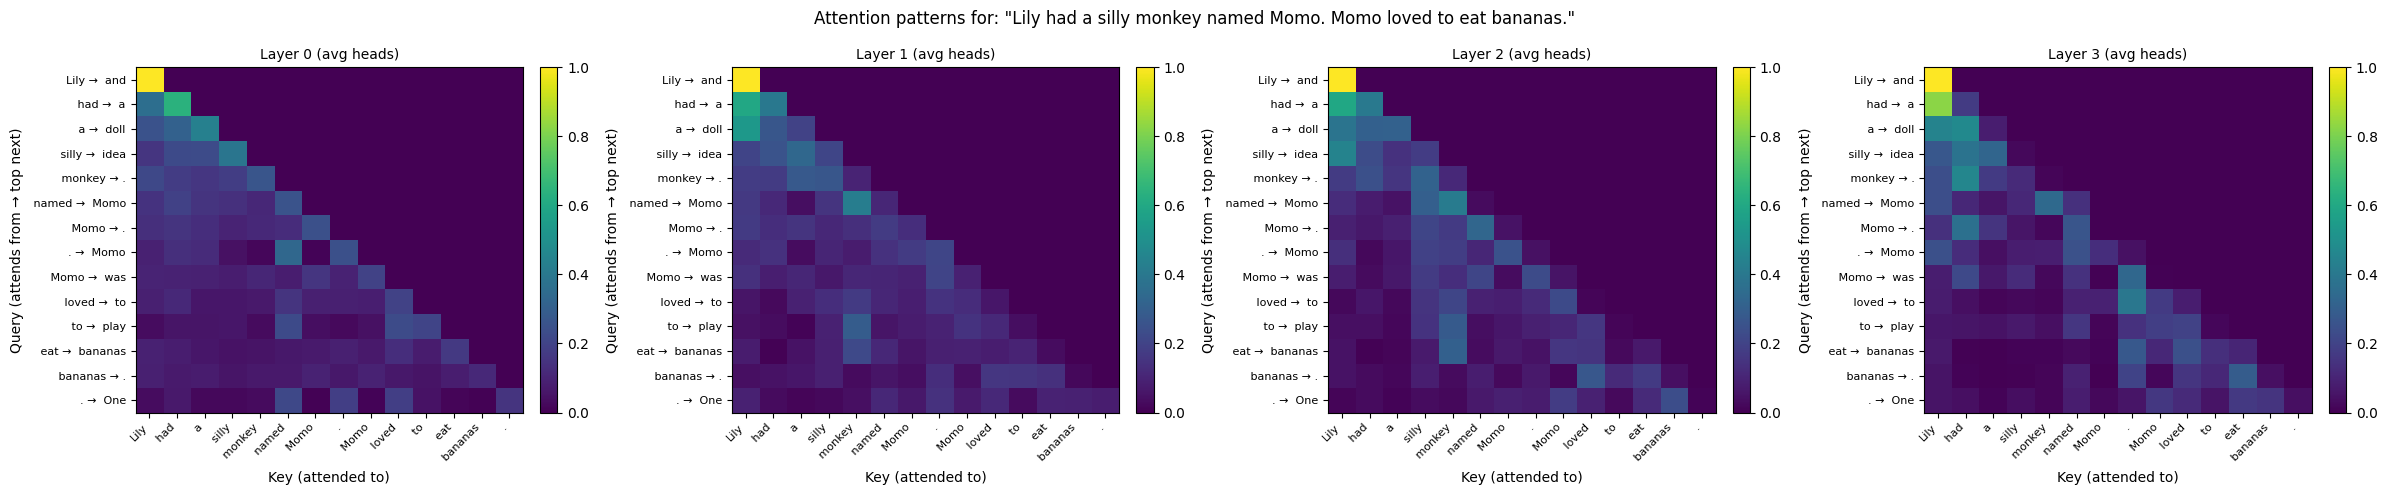

In [95]:
prompt = "Lily had a silly monkey named Momo. Momo loved to eat bananas."
attn_weights = visualize_attention_with_top_next(tlm, tokenizer, text=prompt, layers=None, heads=None)

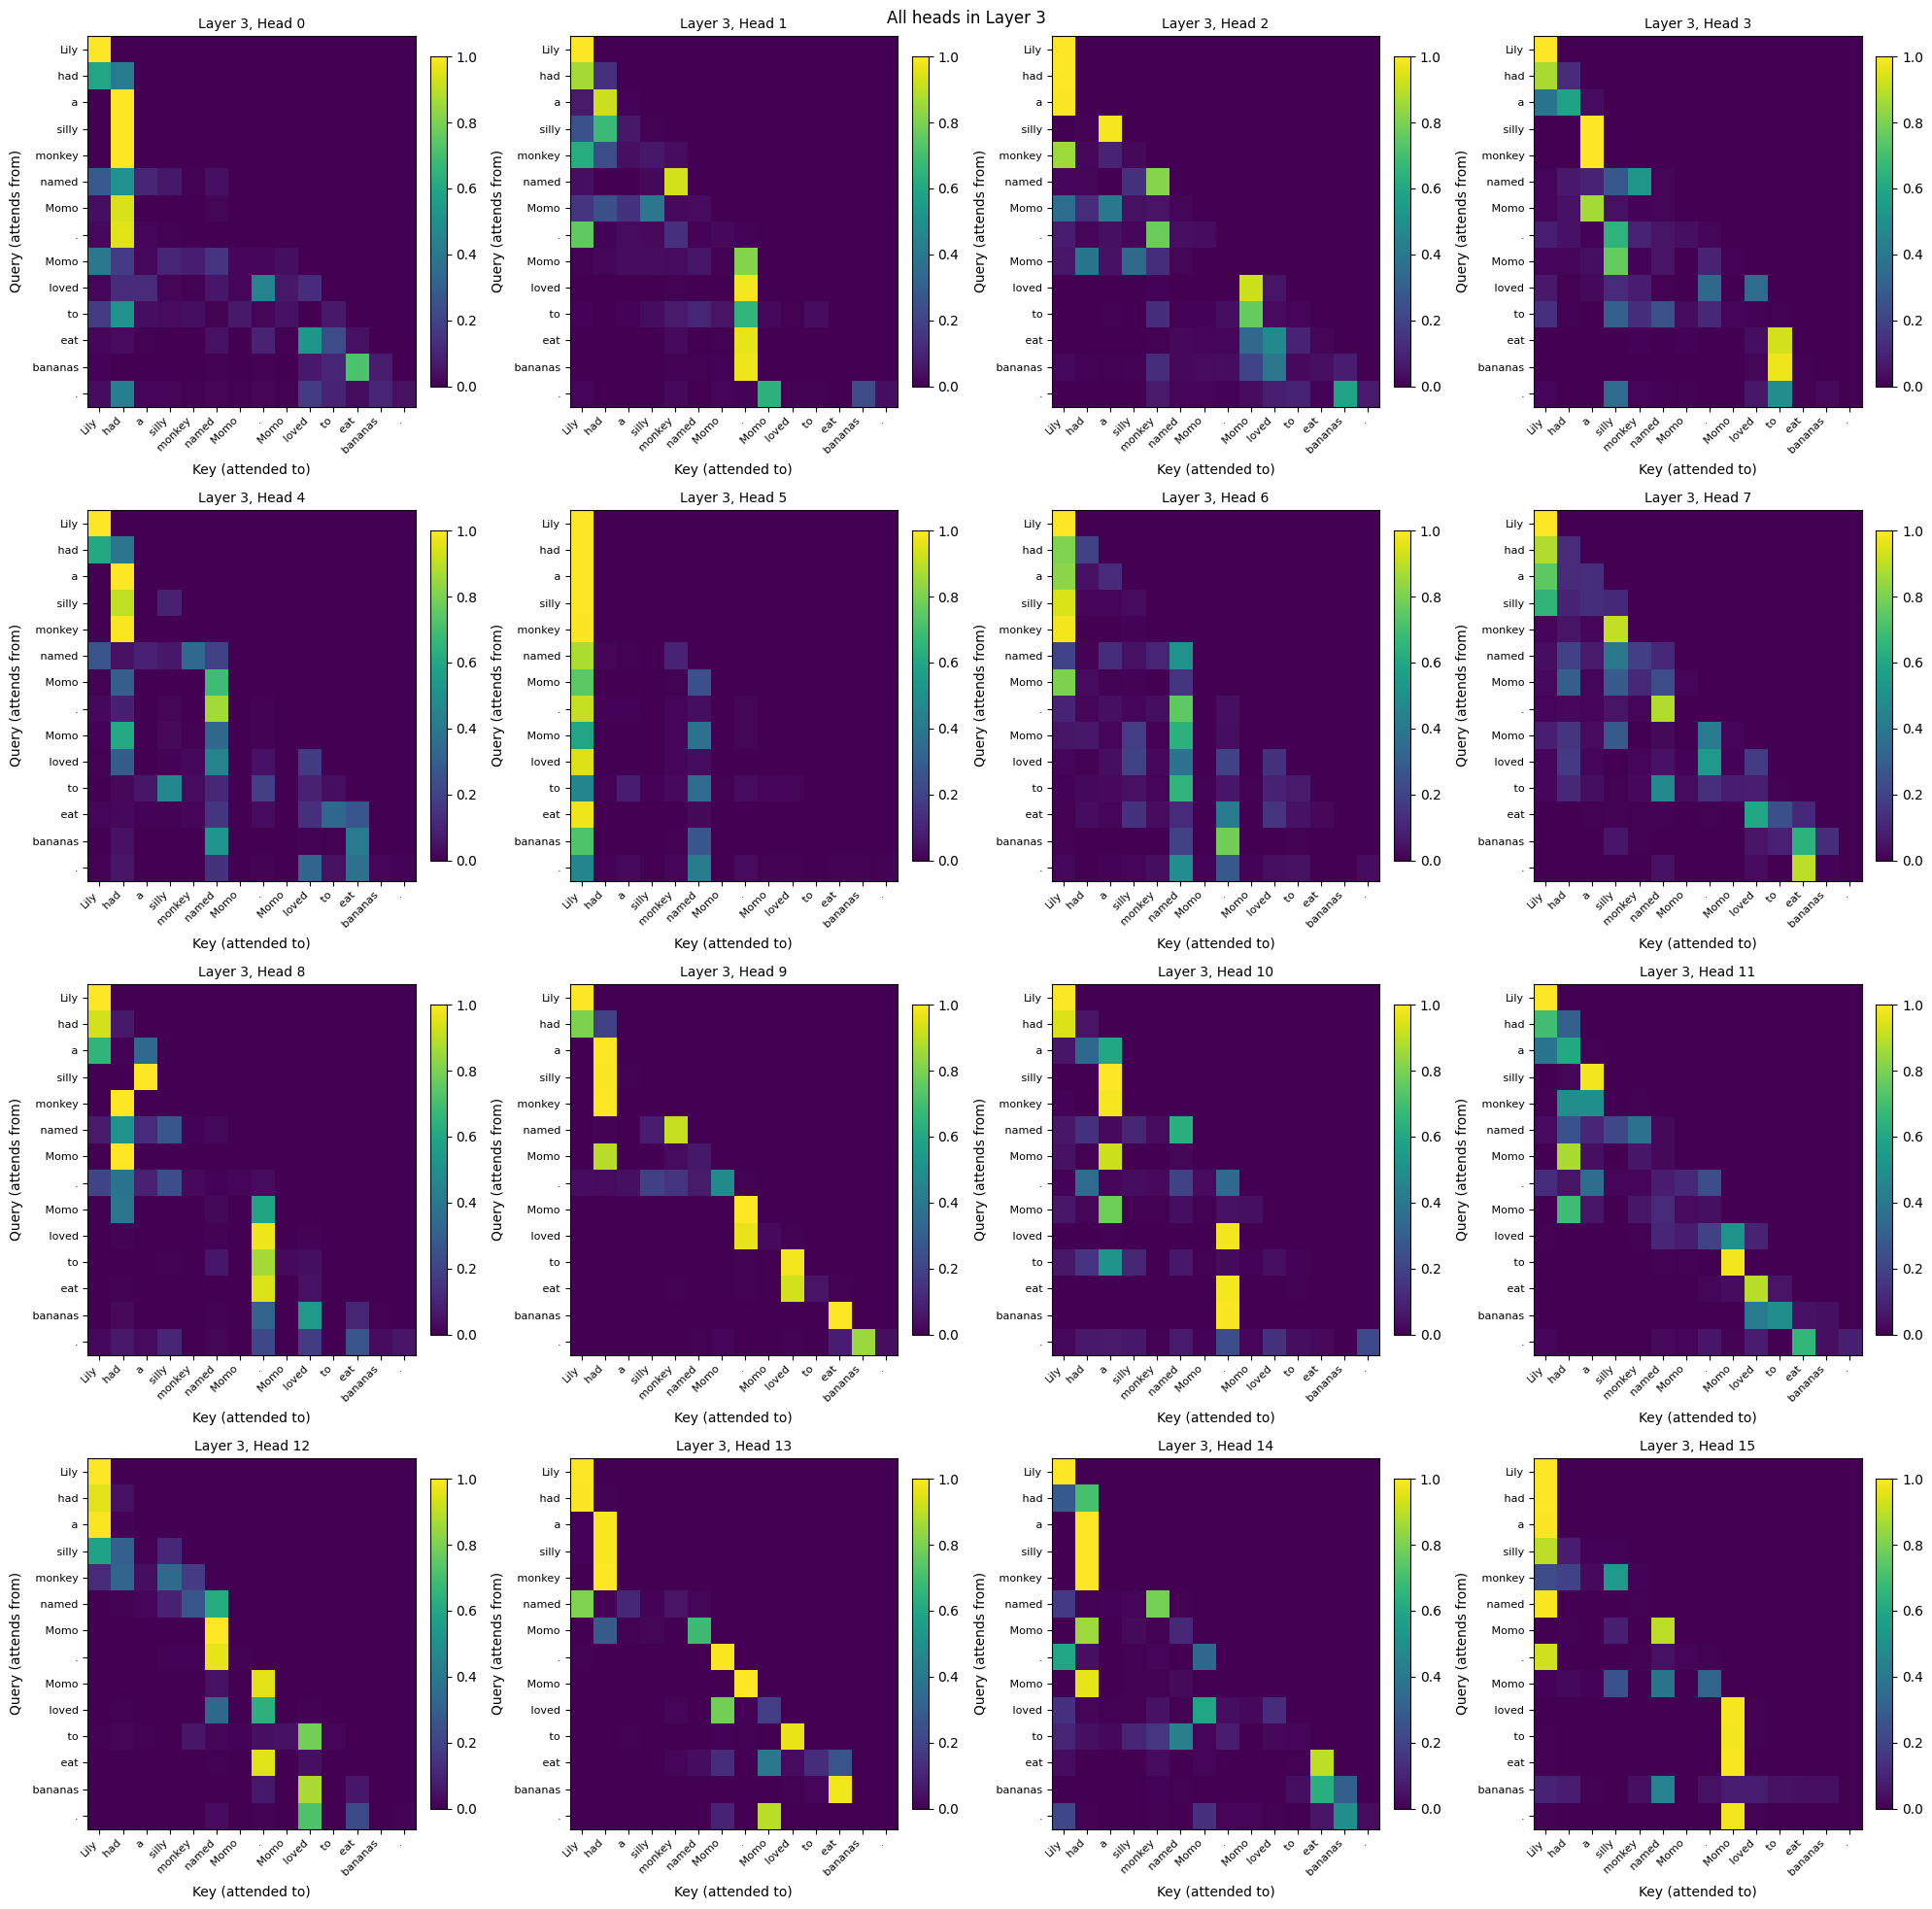

Saved plots and HTML page to: ./tmp/attention_plots/lily_had_a_silly_monkey_named_momo__momo_loved_to_eat_banana/index.html


In [96]:
html_overview = visualize_all_heads_all_layers(attn_weights, tokenizer, prompt, max_heads=16, layers = [3])